# 06 - Confronto tra coorti (anes vs awk)

Confronti EXP vs SHAM puramente entro la stessa coorte (es. EXP vs SHAM solo in anes) sono
poco informativi: le due coorti anes/awk sono animali disgiunti (date di scan diverse), quindi
non e' chiaro se una differenza rifletta l'effetto della lesione/DREADD o solo una differenza
di batch tra le coorti. Questo notebook si concentra invece sui confronti che usano la
struttura anes vs awk:

- **Bf_DTA**: flexibility per nodo, EXP vs SHAM, attraverso lo stato anes -> awk (interazione
  Group x State).
- **Bf_PV**: effetto specifico del CNO (difference-in-differences CNO - baseline, EXP vs SHAM)
  confrontato tra le coorti anes e awk, con test parametrico (Welch) + non parametrico
  (Mann-Whitney), correzione FDR (Benjamini-Hochberg) ed effect size (Hedges' g / rank-biserial).

## Step 1 - Inventario dei dati

Prima di tutto esploriamo `outputs/community_detection/leiden_flex_*` per capire quali scan sono disponibili.
Organizziamo i soggetti in un dizionario `{data: [topi]}`:
- la chiave e' la data dello scan (es. `230908`)
- i valori sono le lettere dei topi scansionati quel giorno (es. `a`, `b`, `c`, `d`)

In [1]:
import os
import re
from collections import defaultdict
from glob import glob
import seaborn as sns
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, mannwhitneyu

In [2]:
OUTPUTS_DIR = "../outputs/community_detection"


def latest_leiden_output_dir(outputs_dir: str, dataset: str) -> str:
    """Return the most recently produced outputs/community_detection/leiden_flex_<n_runs>_<timestamp>/ dir containing `dataset`."""
    candidates = [
        d for d in glob(os.path.join(outputs_dir, "leiden_flex_*"))
        if os.path.isdir(os.path.join(d, dataset))
    ]
    assert candidates, f"No leiden_flex_* output directories containing {dataset!r} found in {outputs_dir}"
    return max(candidates, key=os.path.getmtime)


DATASET = "Bf_DTA_anes"
LEIDEN_DIR = latest_leiden_output_dir(OUTPUTS_DIR, DATASET)
LEIDEN_DIR

'../outputs/community_detection/leiden_flex_20_20260611_121947'

In [3]:
# Le cartelle soggetto hanno il formato "sub-<prefisso><data>", es. "sub-ag230908".
# All'interno, ogni scan e' "sub-<prefisso><data><topo>_<condition>...csv", es. "sub-ag230908a_EXP_bold_parcellated.csv".
SUBJECT_DIR_RE = re.compile(r"^sub-[a-zA-Z]+(\d+)$")


def build_subjects_by_date(leiden_dir, dataset):
    """Map each scan date to the sorted list of mouse letters scanned that day.

    Reads `<leiden_dir>/<dataset>/*/sub-*` folders (named "sub-<prefix><date>") and the
    scan CSVs inside each one (named "sub-<prefix><date><mouse>_<condition>...csv").
    """
    subjects_by_date = defaultdict(set)
    for subject_dir in glob(os.path.join(leiden_dir, dataset, "*", "sub-*")):
        subject_folder = os.path.basename(subject_dir)
        match = SUBJECT_DIR_RE.match(subject_folder)
        if not match:
            continue
        date = match.group(1)
        for csv_path in glob(os.path.join(subject_dir, "*.csv")):
            scan_id = os.path.basename(csv_path).split("_")[0]  # es. "sub-ag230908a"
            mouse = scan_id[len(subject_folder):]  # es. "a"
            subjects_by_date[date].add(mouse)
    return {date: sorted(mice) for date, mice in sorted(subjects_by_date.items())}


subjects_by_date = build_subjects_by_date(LEIDEN_DIR, DATASET)
subjects_by_date


{'230908': ['a'],
 '230911': ['a', 'b', 'c', 'd'],
 '230912': ['a', 'b', 'c', 'd'],
 '230913': ['a', 'b', 'c', 'd'],
 '230914': ['a', 'b', 'c', 'd'],
 '230915': ['a'],
 '230918': ['a', 'b', 'c', 'd'],
 '230919': ['a', 'b', 'c', 'd'],
 '230920': ['a', 'b', 'c'],
 '230921': ['a', 'b', 'c', 'd'],
 '230922': ['a', 'b', 'c', 'd'],
 '230925': ['a', 'b', 'c'],
 '230926': ['a', 'b']}

In [4]:
# Bf_PV dataset inventory (anes cohort): scan dates and mouse letters available,
# same structure as Bf_DTA_anes above.

DATASET_PV = "Bf_PV_anes"
LEIDEN_DIR_PV = latest_leiden_output_dir(OUTPUTS_DIR, DATASET_PV)
subjects_by_date_pv = build_subjects_by_date(LEIDEN_DIR_PV, DATASET_PV)
subjects_by_date_pv


{'240718': ['a', 'b'],
 '240719': ['b', 'c'],
 '240722': ['a'],
 '240723': ['a'],
 '240724': ['a', 'b', 'c'],
 '240725': ['a', 'b', 'c'],
 '240726': ['a', 'b', 'c'],
 '240729': ['a', 'b', 'c', 'd'],
 '240730': ['a', 'b', 'c', 'd'],
 '240731': ['a', 'b', 'c'],
 '240801': ['b', 'c', 'd'],
 '240802': ['a', 'c', 'd'],
 '240806': ['a', 'b', 'c'],
 '240807': ['a', 'b', 'c'],
 '240808': ['a', 'b', 'c']}

In [5]:
# Bf_DTA: flexibility by group (EXP/SHAM) x state (anes/awk), per node.
# This is the visual version of the Group x State interaction test: parallel
# EXP/SHAM lines across anes -> awk mean no state-dependence of the lesion effect;
# diverging/crossing lines mean anesthesia masks (or reveals) it.

DATASET_ANES = "Bf_DTA_anes"
DATASET_AWK = "Bf_DTA_awk"

DATASET_PV = "Bf_PV_anes"
DATASET_PV_AWK = "Bf_PV_awk"

def load_flex_long(dataset):
    """Tidy long-format flexibility table for `dataset`: one row per node per scan,
    with `mouse_id`, `condition` (EXP/SHAM) and `phase` (baseline/CNO/NA) columns.
    Reuses build_subjects_by_date."""
    leiden_dir = latest_leiden_output_dir(OUTPUTS_DIR, dataset)
    subjects_by_date = build_subjects_by_date(leiden_dir, dataset)

    # Store all the per-scan dataframes in a list, then concatenate them at the end.
    records = []
    for date, mice in subjects_by_date.items():
        for mouse in mice:
            csv_paths = glob(os.path.join(leiden_dir, dataset, "*", f"sub-*{date}", f"sub-*{date}{mouse}_*.csv"))
            for csv_path in csv_paths:
                fname = os.path.basename(csv_path)
                condition = fname.split("_")[1]  # "EXP" or "SHAM"
                # Bf_PV_* scans are split into baseline/CNO; Bf_DTA_* scans have no such split.
                if "baseline" in fname:
                    phase = "baseline"
                elif "CNO" in fname:
                    phase = "CNO"
                else:
                    phase = "NA"

                df = pd.read_csv(csv_path)

                # Add `mouse_id`, `condition`, `phase` columns to the dataframe
                df["mouse_id"] = f"{date}{mouse}"
                df["condition"] = condition
                df["phase"] = phase

                # Append it to the records list.
                records.append(df)

    # Concatenate all the per-scan dataframes into a single long-format dataframe and return it.
    return pd.concat(records, ignore_index=True)

state  condition
anes   EXP          22
       SHAM         20
awk    EXP          16
       SHAM         17
Name: mouse_id, dtype: int64


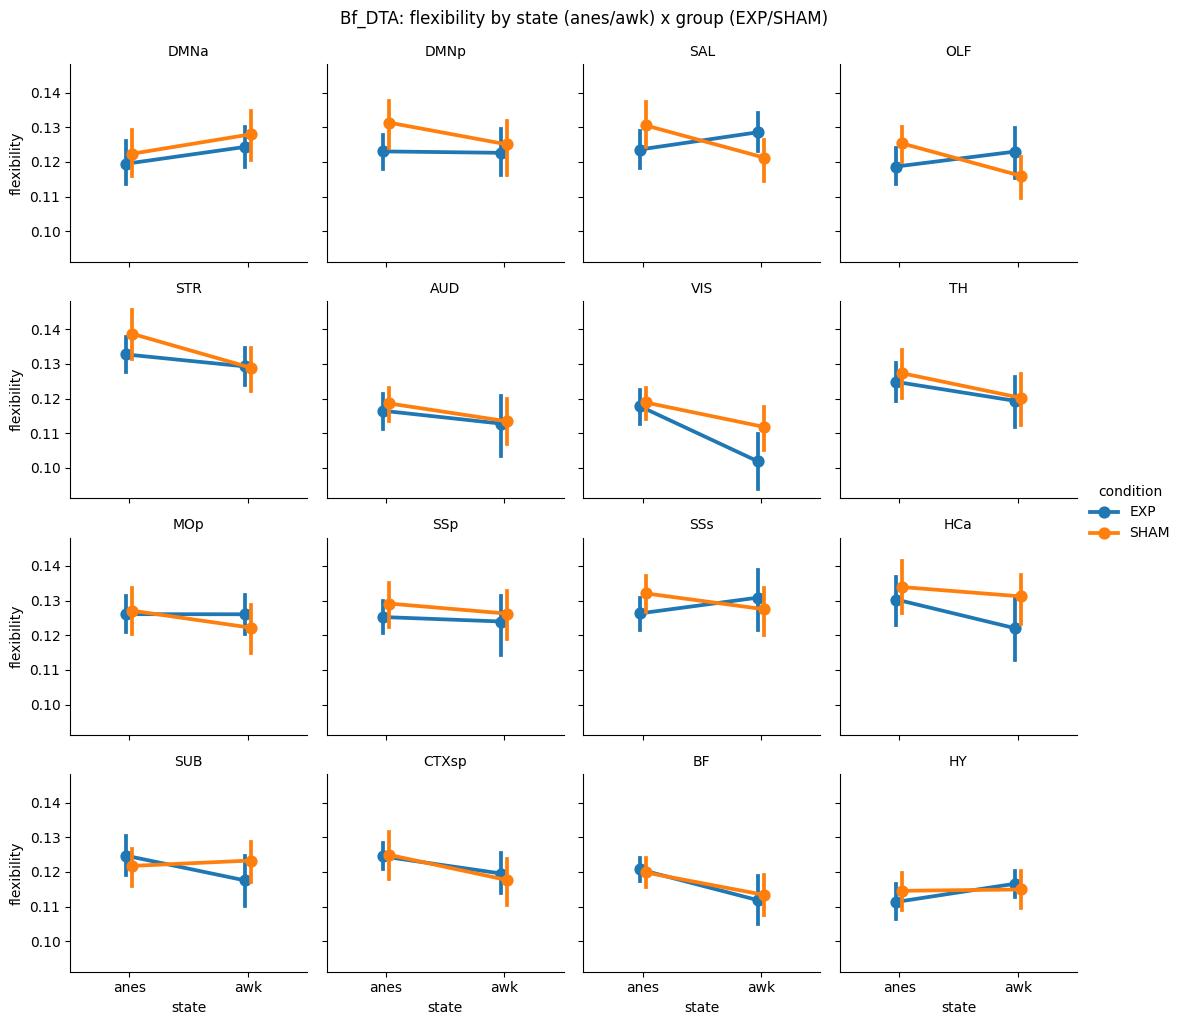

In [6]:

flex_dta = pd.concat([
    load_flex_long(DATASET_ANES).assign(state="anes"),
    load_flex_long(DATASET_AWK).assign(state="awk"),
], ignore_index=True)

print(flex_dta.drop_duplicates(["mouse_id", "condition", "state"]).groupby(["state", "condition"])["mouse_id"].nunique())

# Col = node splits the dataframe into one subset per node value
# X = state (anes/awk) is the x-axis
# Hue = condition (EXP/SHAM) is the color of the lines
# Flexibility is the y-axis, with 95% confidence intervals as error bars

g = sns.catplot(
    data=flex_dta, kind="point",
    x="state", y="flexibility", hue="condition",
    col="Node", col_wrap=4, dodge=True, errorbar=("ci", 95),
    height=2.5, aspect=1.1,
)
g.set_titles("{col_name}")
g.fig.suptitle("Bf_DTA: flexibility by state (anes/awk) x group (EXP/SHAM)", y=1.02)
plt.show()

## Effect size

Le statistiche dei test (t, U) e i p-value dicono se una differenza e' statisticamente
significativa, ma non quanto e' grande. Per il confronto EXP vs SHAM nel DiD qui sotto
aggiungiamo quindi **Hedges' g** (Cohen's d corretto per il bias da campioni piccoli) e la
**correlazione rank-biserial** (equivalente non parametrico di g, ricavata da U).

Non usiamo il relative risk: la nostra variabile di outcome (flexibility) e' continua, non
un evento binario/una proporzione, quindi RR non e' applicabile senza arbitrariamente
discretizzare i dati (perdendo informazione).

In [7]:
def hedges_g(x, y):
    """Bias-corrected Cohen's d (Hedges' g) for two independent samples."""
    x, y = np.asarray(x), np.asarray(y)
    nx, ny = len(x), len(y)
    pooled_sd = np.sqrt(((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / (nx + ny - 2))
    d = (x.mean() - y.mean()) / pooled_sd
    correction = 1 - 3 / (4 * (nx + ny - 2) - 1)
    return d * correction


def rank_biserial(u_stat, n1, n2):
    """Rank-biserial correlation from a Mann-Whitney U statistic (U for the first sample, x)."""
    return (2 * u_stat) / (n1 * n2) - 1

In [8]:
# Bf_PV: CNO-specific effect (difference-in-differences) compared anes vs awk.
# Comparing raw flexibility levels between Bf_PV_anes and Bf_PV_awk is confounded: the two
# state cohorts are disjoint animals (different scan dates), so any EXP vs SHAM gap could be a
# pre-existing batch difference rather than a CNO effect. The within-animal CNO-baseline delta
# cancels out each cohort's own baseline confound, so comparing
#   DiD_state = (EXP_CNO - EXP_baseline) - (SHAM_CNO - SHAM_baseline)
# between anes and awk is a true State x Condition x Phase test: "is the CNO-specific effect
# different in magnitude/sign when awake vs anesthetized?", not "is awake flexibility lower
# than anesthetized flexibility?".

flex_pv_state = pd.concat([
    load_flex_long(DATASET_PV).assign(state="anes"),
    load_flex_long(DATASET_PV_AWK).assign(state="awk"),
], ignore_index=True)

print(
    flex_pv_state
    .drop_duplicates(["mouse_id", "condition", "phase", "state"])
    .groupby(["state", "condition", "phase"])["mouse_id"]
    .nunique()
)


def benjamini_hochberg(pvals):
    """Return Benjamini-Hochberg FDR-adjusted p-values, in the input order."""
    p = np.asarray(pvals, dtype=float)
    n = len(p)
    order = np.argsort(p)
    adjusted = p[order] * n / (np.arange(n) + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]  # enforce monotonicity
    out = np.empty(n)
    out[order] = np.clip(adjusted, 0, 1)
    return out


def difference_in_differences(flex_df):
    """Per-node DiD test: is (CNO - baseline) different between EXP and SHAM?

    Expects a tidy frame with columns subject, condition, phase, Node, flexibility.
    Only animals that have BOTH phases contribute. Returns one row per node with
    raw Welch / Mann-Whitney p-values, their FDR-corrected counterparts, and effect sizes
    (Hedges' g for the Welch comparison, rank-biserial r for the Mann-Whitney one).
    """

    # Pivot to have one row per subject/condition/Node,
    # with separate columns for baseline and CNO flexibility.
    deltas = (
        flex_df
        .pivot_table(index=["subject", "condition", "Node"], columns="phase", values="flexibility")
        .dropna(subset=["baseline", "CNO"])
        .reset_index()
    )
    deltas["delta"] = deltas["CNO"] - deltas["baseline"]

    rows = []
    for node in sorted(deltas["Node"].unique()):
        d_exp = deltas.loc[(deltas.condition == "EXP") & (deltas.Node == node), "delta"]
        d_sham = deltas.loc[(deltas.condition == "SHAM") & (deltas.Node == node), "delta"]
        t_stat, t_p = ttest_ind(d_exp, d_sham, equal_var=False)
        u_stat, u_p = mannwhitneyu(d_exp, d_sham, alternative="two-sided")
        rows.append({
            "Node": node,
            "n_EXP": len(d_exp), "n_SHAM": len(d_sham),
            "delta_EXP": d_exp.mean(), "delta_SHAM": d_sham.mean(),
            "DiD": d_exp.mean() - d_sham.mean(),
            "t_p_value": t_p, "hedges_g": hedges_g(d_exp, d_sham),
            "u_p_value": u_p, "rank_biserial": rank_biserial(u_stat, len(d_exp), len(d_sham)),
        })
    res = pd.DataFrame(rows)
    res["t_p_fdr"] = benjamini_hochberg(res["t_p_value"])
    res["u_p_fdr"] = benjamini_hochberg(res["u_p_value"])
    return res.sort_values("t_p_value").reset_index(drop=True)


# difference_in_differences expects a "subject" column (it was written for phase_df,
# which uses that name); flex_pv_state uses "mouse_id" for the same thing.
flex_pv_state_for_did = flex_pv_state.rename(columns={"mouse_id": "subject"})

did_by_state = pd.concat([
    difference_in_differences(flex_pv_state_for_did.loc[flex_pv_state_for_did["state"] == "anes"]).assign(state="anes"),
    difference_in_differences(flex_pv_state_for_did.loc[flex_pv_state_for_did["state"] == "awk"]).assign(state="awk"),
], ignore_index=True)

did_by_state[["state", "Node", "n_EXP", "n_SHAM", "delta_EXP", "delta_SHAM", "DiD", "t_p_value", "t_p_fdr", "hedges_g", "rank_biserial"]]


state  condition  phase   
anes   EXP        CNO         21
                  baseline    21
       SHAM       CNO         20
                  baseline    18
awk    EXP        CNO          9
                  baseline    11
       SHAM       CNO          9
                  baseline     9
Name: mouse_id, dtype: int64


,state,Node,n_EXP,n_SHAM,delta_EXP,delta_SHAM,DiD,t_p_value,t_p_fdr,hedges_g,rank_biserial
0,anes,TH,21,18,-0.003241,0.004209,-0.007450,0.050283,0.315048,-0.628582,-0.322751
1,anes,SUB,21,18,-0.004314,0.004873,-0.009187,0.060491,0.315048,-0.630339,-0.301587
2,anes,VIS,21,18,-0.001127,0.006910,-0.008037,0.072354,0.315048,-0.581246,-0.396825
3,anes,HY,21,18,-0.002071,0.003680,-0.005751,0.084935,0.315048,-0.552282,-0.296296
4,anes,HCa,21,18,-0.003000,0.004351,-0.007351,0.120635,0.315048,-0.510018,-0.269841
5,anes,STR,21,18,-0.005714,0.002474,-0.008188,0.122986,0.315048,-0.508912,-0.306878
6,anes,DMNp,21,18,0.000437,0.007123,-0.006685,0.138632,0.315048,-0.480145,-0.291005
7,anes,SSp,21,18,-0.003352,0.003359,-0.006711,0.157524,0.315048,-0.466265,-0.312169
8,anes,DMNa,21,18,-0.002401,0.004820,-0.007221,0.179175,0.318533,-0.444506,-0.280423
9,anes,BF,21,18,-0.001546,0.004208,-0.005754,0.216614,0.346582,-0.396030,-0.195767


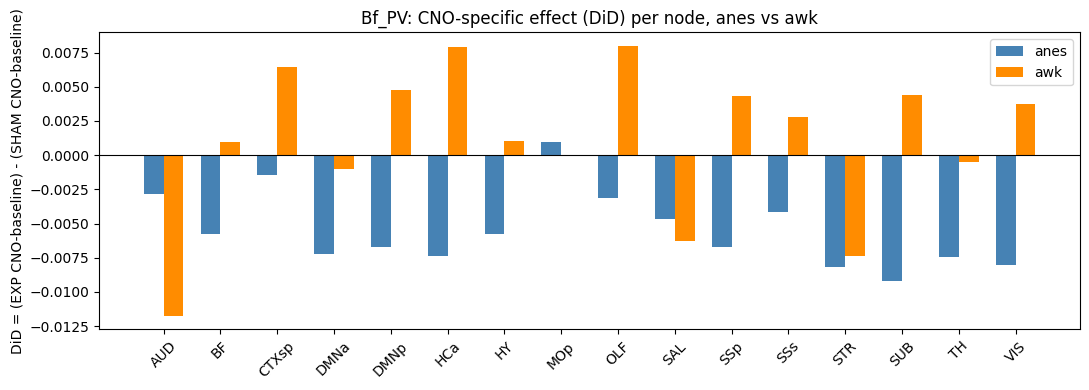

In [9]:
# Side-by-side per-node DiD comparison: bars above 0 mean EXP's CNO-baseline change is
# larger (less negative / more positive) than SHAM's; bars below 0 mean the opposite.
# Comparing the anes and awk bars per node shows where the two cohorts agree or disagree
# on the direction/magnitude of the CNO-specific effect.

node_order = sorted(did_by_state["Node"].unique())
did_pivot = did_by_state.pivot(index="Node", columns="state", values="DiD").reindex(node_order)

x = np.arange(len(node_order))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - width / 2, did_pivot["anes"], width=width, label="anes", color="steelblue")
ax.bar(x + width / 2, did_pivot["awk"], width=width, label="awk", color="darkorange")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(node_order, rotation=45)
ax.set_ylabel("DiD = (EXP CNO-baseline) - (SHAM CNO-baseline)")
ax.set_title("Bf_PV: CNO-specific effect (DiD) per node, anes vs awk")
ax.legend()
plt.tight_layout()
plt.show()
